## **DS522: Data Acquisition and Analytics - USADL - Spring 2025-2026, PyForce**
### **FHIR Data Obfuscation for Population-Level Analytics**

>   **School of Technology and Computing**<br>
    **City University of Seattle** <br>
    *Seattle, WA 98121* <br>

`Makenzy Abass Gumah, `<br> 
`gumahmakenzyabass@cityuniversity.edu`

`Jacqueline Biira, `<br>
`biirajacqueline@cityuniversity.edu`

`Dawit Hailu, MSAI`<br>
`hailudawith@cityuniversity.edu`

### **Bulk Import FHIR data:**

#### *Library Imports:*

In [1]:
from bulk_import import FHIRBulkLoader # import loader class from bulk_import.py

import pprint as prettyPrnt
import pandas as pd
import requests
import os

## **!!! NOTE !!!**
### please remember to add **FHIR_SERVER** to Environment variables
*http://**[server ip shared on Teams]**:8080/fhir*

In [2]:
print(os.environ.get('FHIR_SERVER'))

http://107.22.53.0:8080/fhir


In [3]:

from bulk_import import FHIRBulkLoader

FHIR_SERVER = os.environ.get('FHIR_SERVER') # Get FHIR server URL from environment variable
ZIP_FILE = "synthea_sample_data_fhir_r4_nov2021.zip" #initial data loaded Ref: https://mitre.box.com/shared/static/ylzmiichhvtw1igr4ck6q32i5b333nqs.zip
COVID_ZIP_FILE = "10k_synthea_covid19_csv.zip" #COVID-19 data loaded Ref: https://mitre.box.com/shared/static/9iglv8kbs1pfi7z8phjl9sbpjk08spze.zip

# loader = FHIRBulkLoader(base_url=FHIR_SERVER, max_workers=2)
# # loader.load_from_zip(ZIP_FILE)
# loader.load_from_zip(COVID_ZIP_FILE, file_type='csv')

### **1. Test API Access:**
>
    In this section we will test AWS FHIR API access and presence of patient data uploaded during initial setup. 

#### 1.1. **Patient Getter Function Definition** 

In [4]:
def get_patient_data(base_url):
    # Search for all Patients
    response = requests.get(f"{base_url}/Patient?_summary=true", timeout=30)
    if response.status_code == 200:
        bundle = response.json()
        # Extract specific fields for analysis
        patients = []
        for entry in bundle.get('entry', []):
            resource = entry['resource']
            patients.append({
                'id': resource.get('id'),
                'gender': resource.get('gender'),
                'birthDate': resource.get('birthDate')
            })
        return pd.DataFrame(patients)
    return pd.DataFrame()

#### 1.2 **Test Summary Count And Sample Patient Information**

In [5]:
# get patient cout
response = requests.get(f"{FHIR_SERVER}/Patient?_summary=count", timeout=30)
if response.status_code == 200:
    count = response.json().get('total', 0)
    print(f"Total Patients: {count}")
else:
    print(f"Failed to retrieve patient count: {response.status_code}")
# view the first few rows of the patient data
df = get_patient_data(FHIR_SERVER)
print(df.head())

Total Patients: 12152
                                     id  gender   birthDate
0  6fce0e81-8447-4848-a811-57fa69303478    male  1956-12-23
1  39d974ab-03f0-4589-b9ab-849529c05135  female  1994-05-31
2  b4c25ec7-1b48-4ec9-83d4-c928d2c2f023    male  1995-01-22
3  355c953f-214d-4e40-868e-6358fed6927e    male  2003-11-09
4  fc45bb1f-5031-485a-8590-691d94cfe25c    male  1923-07-20


### 2. **Data Analysis:**
>
    In this section we will perform patient level data analytics, perform de-identification on population level data, and finnally visualize patient-level data suplimenting with global data analytics.

#### 2.1. **Patient Data Analysis:**

In [6]:
from analysis_module import FHIRDataAnalyzer

analyzer = FHIRDataAnalyzer(base_url=FHIR_SERVER)

sample_patient_id = df['id'].iloc[0] if not df.empty else None
prettyPrnt.pprint(f"Analyzing data for patient ID: {sample_patient_id}")

'Analyzing data for patient ID: 6fce0e81-8447-4848-a811-57fa69303478'


In [7]:
sample_patient_data = analyzer.get_patient_data(sample_patient_id)
prettyPrnt.pprint(sample_patient_data)

{'birthDate': '1956-12-23',
 'gender': 'male',
 'id': '6fce0e81-8447-4848-a811-57fa69303478',
 'meta': {'lastUpdated': '2026-05-14T00:52:35.084+00:00', 'versionId': '1'},
 'name': [{'family': 'Conroy74', 'given': ['Floyd420']}],
 'resourceType': 'Patient'}


In [8]:
COVID_SYMPTOM_CODES = {
    "Conjunctival Congestion": "698755008",
    "Nasal Congestion": "68235000",
    "Headache": "25064002",
    "Cough": "49727002",
    "Sore Throat": "267102003",
    "Sputum Production": "248595008",
    "Fatigue": "84229001",
    "Hemoptysis": "66857006",
    "Shortness of Breath": "267036007",
    "Nausea": "422587007",
    "Diarrhea": "62315008",
    "Muscle Pain": "68962001",
    "Joint Pain": "57676002",
    "Chills": "43724002",
    "Loss of Taste": "441695007",
    "COVID_19_Pneumonia": "840539006",
    "COVID_19": "840544004"
}


In [9]:
# pick random patient ID for testing
SAMPLE_PATIENT_ID = df.sample(1)['id'].iloc[0] if not df.empty else None
# get all observations for that patient
sample_patient_covid_symptoms = analyzer.get_covid_symptoms_by_patient(SAMPLE_PATIENT_ID, COVID_SYMPTOM_CODES)
prettyPrnt.pprint(sample_patient_covid_symptoms)

{'patient_id': '10f76834-730a-4076-96fe-d24202c059fe', 'symptoms_count': 0}


In [10]:
# now, let's check if a patient has a condition with the COVID-19 code.

SAMPLE_PATIENT_ID = df.sample(1)['id'].iloc[0] if not df.empty else None

result = analyzer.patient_has_covid(SAMPLE_PATIENT_ID)
print(f"Patient {SAMPLE_PATIENT_ID} has COVID-19: {result}")

Patient 472e249b-1ada-4ae0-9333-3490ae5a2501 has COVID-19: True


### 3. **Data Visualization:**
#### 3.1 **Symptoms By Age**
>
    Here, we will visualize symptoms, covid condition and patient details.

In [11]:
df_sample_patients = pd.DataFrame(analyzer.get_patients(count=1000)) #returns 500 by default, can specify count in method call
print(df_sample_patients.shape)
# get sample patient ids
# df_sample_patients = df_patients.sample(1000)
# print(df_sample_patients.shape)
visualization_data = []

for patient in df_sample_patients.itertuples():
    patient_id = patient.id
    
    b_date = patient.birthDate
    
    if b_date:
        age_group = analyzer.get_patient_age_group(birth_date=b_date)
    else:
        age_group = "Unknown"

    symptom_count = analyzer.get_covid_symptoms_by_patient(patient_id, COVID_SYMPTOM_CODES)['symptoms_count']
    covid_positive = "Positive" if analyzer.patient_has_covid(patient_id) else "Negative"
    
    # print(f"Patient ID: {patient_id}, Age Group: {age_group}, Symptom Count: {symptom_count}, COVID Positive: {covid_positive}")
    
    visualization_data.append({
        "patient_id": patient_id,
        "age_group": age_group,
        "symptom_count": symptom_count,
        "covid_positive": covid_positive
    })

(1000, 6)


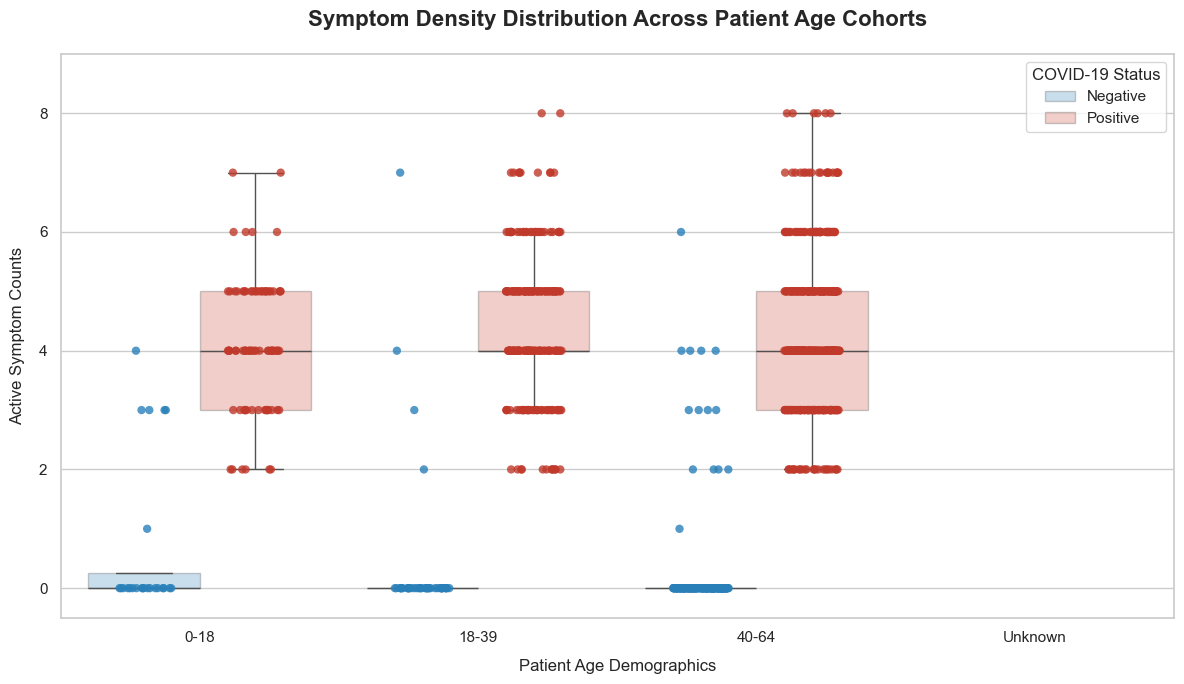

In [12]:
analyzer.covid_symptom_distribution_by_age_group(visualization_data)  